# VIV S4 — All Datasets, No Stride, Random Sequence Split

Trains S4 using 5 sensors to predict scaled POD modes and reconstructs full fields.
Key differences from `viv_s4_single_series.ipynb`:
- **All** VIV CSV files are loaded (no single-file filter)
- **No spatial stride** (full spatial resolution)
- Trajectories are cut into **non-overlapping** windows of `seq_len=1000`
- Windows are **randomly shuffled** and split 80 / 10 / 10 (train / valid / test)

## 1. Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils.extmath import randomized_svd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


## 2. Load All VIV Trajectories (no stride)

In [48]:
data_dir = Path('../NDP38m_extracted_csv')
csv_files = sorted(data_dir.glob('DISPL*.csv'))
if len(csv_files) == 0:
    raise FileNotFoundError(f'No CSV files found in {data_dir}')

# Load ALL files without any spatial stride
stride = 1
fields, names = [], []
for fp in csv_files[1:2][::2]:
    raw = pd.read_csv(fp).to_numpy()[:,::stride]          # shape: [T, Nx_raw]
    field = raw.T.astype(np.float32)          # shape: [T, Nx]
    fields.append(field)
    names.append(fp.name)

Nx = min(f.shape[1] for f in fields)
all_fields = [f for f in fields]    # crop to common spatial length
lengths = [f.shape[0] for f in all_fields]

print(f'Loaded {len(all_fields)} trajectories:')
for n, f in zip(names, all_fields):
    print(f'  {n}: shape={f.shape}')

Loaded 1 trajectories:
  DISPL2040_DISPLIL.csv: shape=(35000, 200)


## 3. Non-Overlapping Sequence Windows + Random Split

In [51]:
n_sensors   = 6
seq_len     = 1000
train_ratio = 0.80
valid_ratio = 0.10
n_modes     = 12    # number of POD modes to predict
seed        = 42

sensor_idx = [int((i + 1) * Nx / (n_sensors + 1)) for i in range(n_sensors)]

# 1. Cut every trajectory into non-overlapping windows of seq_len (drop remainder)
all_seqs = []
for traj in all_fields:
    n_seqs = traj.shape[0] // seq_len
    for i in range(n_seqs):
        all_seqs.append(traj[i * seq_len:(i + 1) * seq_len])

print(f'Total non-overlapping sequences (seq_len={seq_len}): {len(all_seqs)}')

# 2. Randomly shuffle and split into train / valid / test
rng = np.random.default_rng(seed)
indices = np.arange(len(all_seqs))
rng.shuffle(indices)

n_total = len(indices)
n_train = int(train_ratio * n_total)
n_valid = int(valid_ratio * n_total)

train_idx = indices[:n_train]
valid_idx = indices[n_train:n_train + n_valid]
test_idx  = indices[n_train + n_valid:]

train_seqs = [all_seqs[i] for i in train_idx]
valid_seqs = [all_seqs[i] for i in valid_idx]
test_seqs  = [all_seqs[i] for i in test_idx]

print(f'  train={len(train_seqs)}, valid={len(valid_seqs)}, test={len(test_seqs)}')

# 3. Fit POD basis on training snapshots only (no data leakage)
train_snapshots = np.concatenate(train_seqs, axis=0)    # [T_train, Nx]
train_mean = train_snapshots.mean(axis=0, keepdims=True)
train_std = train_snapshots.std(axis=0, keepdims=True) 
Xc_train = train_snapshots - train_mean
_, _, Vt = randomized_svd(Xc_train, n_components=n_modes, random_state=seed)
Phi = Vt.T.astype(np.float32)                          # [Nx, n_modes]

train_recon = (Xc_train @ Phi) @ Phi.T + train_mean
train_error = np.linalg.norm(train_snapshots - train_recon) / np.linalg.norm(train_snapshots)
print(f'POD reconstruction error on training data: {train_error * 100:.4f} %')

# 4. Build sequence datasets (each window already has the right length)
def build_dataset_from_seqs(seqs, sensor_idx, mean_vec, phi):
    X_list, Y_modes_list, Y_full_list = [], [], []
    for seg in seqs:
        centered = seg - mean_vec
        modes = centered @ phi
        X_list.append(seg[:, sensor_idx])
        Y_modes_list.append(modes)
        Y_full_list.append(seg)
    return (
        np.array(X_list, dtype=np.float32),
        np.array(Y_modes_list, dtype=np.float32),
        np.array(Y_full_list, dtype=np.float32),
    )

X_train, Y_train_modes, Y_train_full = build_dataset_from_seqs(train_seqs, sensor_idx, train_mean, Phi)
X_valid, Y_valid_modes, Y_valid_full = build_dataset_from_seqs(valid_seqs, sensor_idx, train_mean, Phi)
X_test,  Y_test_modes,  Y_test_full  = build_dataset_from_seqs(test_seqs,  sensor_idx, train_mean, Phi)

# 5. Standardise sensors and POD targets
x_scaler = StandardScaler().fit(X_train.reshape(-1, n_sensors))
y_scaler = StandardScaler().fit(Y_train_modes.reshape(-1, n_modes))

X_train_sc = x_scaler.transform(X_train.reshape(-1, n_sensors)).reshape(X_train.shape).astype(np.float32)
X_valid_sc = x_scaler.transform(X_valid.reshape(-1, n_sensors)).reshape(X_valid.shape).astype(np.float32)
X_test_sc  = x_scaler.transform(X_test.reshape(-1,  n_sensors)).reshape(X_test.shape).astype(np.float32)

Y_train_sc = y_scaler.transform(Y_train_modes.reshape(-1, n_modes)).reshape(Y_train_modes.shape).astype(np.float32)
Y_valid_sc = y_scaler.transform(Y_valid_modes.reshape(-1, n_modes)).reshape(Y_valid_modes.shape).astype(np.float32)
Y_test_sc  = y_scaler.transform(Y_test_modes.reshape(-1,  n_modes)).reshape(Y_test_modes.shape).astype(np.float32)

# print(f'Train mean and std (sensors): {train_mean.mean()}, {train_std.mean()}')
print(f'\nSensor indices: {sensor_idx}')
print(f'POD basis shape Phi: {Phi.shape}')
print(f'X_train={X_train_sc.shape}, Y_train_modes={Y_train_sc.shape}')
print(f'X_valid={X_valid_sc.shape}, Y_valid_modes={Y_valid_sc.shape}')
print(f'X_test ={X_test_sc.shape},  Y_test_modes ={Y_test_sc.shape}')

Total non-overlapping sequences (seq_len=1000): 35
  train=28, valid=3, test=4
POD reconstruction error on training data: 6.6530 %

Sensor indices: [28, 57, 85, 114, 142, 171]
POD basis shape Phi: (200, 12)
X_train=(28, 1000, 6), Y_train_modes=(28, 1000, 12)
X_valid=(3, 1000, 6), Y_valid_modes=(3, 1000, 12)
X_test =(4, 1000, 6),  Y_test_modes =(4, 1000, 12)


## 4. S4 Model

In [52]:
def make_hippo_legs(N):
    A = np.zeros((N, N))
    B = np.zeros((N, 1))
    for n in range(N):
        B[n, 0] = (2 * n + 1) ** 0.5
        for k in range(N):
            if n > k:
                A[n, k] = -(2 * n + 1) ** 0.5 * (2 * k + 1) ** 0.5
            elif n == k:
                A[n, k] = -(n + 1)
            elif n < k:
                A[n, k] = 0
    return A, B

class S4Layer(nn.Module):
    def __init__(self, d_input, d_state=64, dropout=0.1, max_len=256):
        super().__init__()
        A_np, B_np = make_hippo_legs(d_state)
        step_init = 0.01
        I_np = np.eye(d_state)
        Ainv = np.linalg.solve(I_np - A_np * step_init / 2, I_np)
        A_bar_np = Ainv @ (I_np + A_np * step_init / 2)
        B_bar_np = (Ainv * step_init) @ B_np

        self.register_buffer('A_bar', torch.tensor(A_bar_np, dtype=torch.float32))
        self.register_buffer('B_bar', torch.tensor(B_bar_np.squeeze(), dtype=torch.float32))

        A_powers_np = np.zeros((max_len, d_state, d_state), dtype=np.float64)
        A_powers_np[0] = np.eye(d_state)
        for k in range(1, max_len):
            A_powers_np[k] = A_powers_np[k - 1] @ A_bar_np.astype(np.float64)
        self.register_buffer('A_powers', torch.tensor(A_powers_np, dtype=torch.float32))

        self.C = nn.Parameter(torch.randn(d_input, d_state) * 0.01)
        self.D = nn.Parameter(torch.randn(d_input) * 0.01)
        self.out_proj = nn.Linear(d_input, d_input)
        self.norm = nn.LayerNorm(d_input)
        self.dropout = nn.Dropout(dropout)

    def _compute_kernel(self, L):
        return torch.einsum('hn,lnm,m->hl', self.C, self.A_powers[:L], self.B_bar)

    def forward(self, u):
        B, L, H = u.shape
        K = self._compute_kernel(L)
        u_f = torch.fft.rfft(u.transpose(1, 2), n=2 * L)
        K_f = torch.fft.rfft(K, n=2 * L)
        y = torch.fft.irfft(u_f * K_f.unsqueeze(0), n=2 * L)[..., :L]
        y = y + u.transpose(1, 2) * self.D.unsqueeze(0).unsqueeze(-1)
        y = y.transpose(1, 2)
        y = self.dropout(F.gelu(self.out_proj(y)))
        y = self.norm(y)
        return y

class S4SequenceModel(nn.Module):
    def __init__(self, n_sensors, n_outputs, d_model=64, d_state=64, n_layers=3, dropout=0.1, max_len=256):
        super().__init__()
        self.input_proj = nn.Linear(n_sensors, d_model)
        self.layers = nn.ModuleList([S4Layer(d_model, d_state=d_state, dropout=dropout, max_len=max_len) for _ in range(n_layers)])
        self.decoder = nn.Sequential(nn.Linear(d_model, 256), nn.GELU(), nn.Linear(256, 512), nn.GELU(), nn.Linear(512, n_outputs))

    def forward(self, x):
        h = self.input_proj(x)
        for layer in self.layers:
            h = h + layer(h)
        return self.decoder(h)

s4_model = S4SequenceModel(
    n_sensors=n_sensors,
    n_outputs=n_modes,
    d_model=512,
    d_state=256,
    n_layers=1,
    dropout=0.1,
    max_len=seq_len,
).to(device)

print(f'S4 params: {sum(p.numel() for p in s4_model.parameters()):,}')

S4 params: 667,916


## 5. DiagSSM Model

In [53]:
class DiagSSMLayer(nn.Module):
    def __init__(self, d_model=128, d_state=128, dropout=0.1):
        super().__init__()
        self.in_proj  = nn.Linear(d_model, d_state)
        self.out_proj = nn.Linear(d_state, d_model)
        self.skip     = nn.Linear(d_model, d_model, bias=False)

        # Stable diagonal dynamics: alpha in (0, 1)
        self.logit_alpha = nn.Parameter(torch.zeros(d_state))
        self.b           = nn.Parameter(torch.randn(d_state) * 0.02)

        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, u):
        B, L, D = u.shape
        inp = self.in_proj(u)                               # [B, L, N]
        alpha = torch.sigmoid(self.logit_alpha).view(1, 1, -1)
        b     = self.b.view(1, 1, -1)
        x = torch.zeros(B, inp.size(-1), device=u.device, dtype=u.dtype)
        ys = []
        for t in range(L):
            x = alpha.squeeze(1) * x + b.squeeze(1) * inp[:, t, :]
            ys.append(x)
        y = torch.stack(ys, dim=1)            # [B, L, N]
        y = self.out_proj(y) + self.skip(u)
        y = self.dropout(F.gelu(y))
        y = self.norm(y)
        return y

class DiagSSMSequenceModel(nn.Module):
    def __init__(self, n_sensors, n_outputs, d_model=128, d_state=128, n_layers=4, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_sensors, d_model)
        self.layers = nn.ModuleList([
            DiagSSMLayer(d_model=d_model, d_state=d_state, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 256),
            nn.GELU(),
            nn.Linear(256, 512),
            nn.GELU(),
            nn.Linear(512, n_outputs),
        )

    def forward(self, x):
        h = self.input_proj(x)
        for layer in self.layers:
            h = h + layer(h)
        return self.decoder(h)

di_model = DiagSSMSequenceModel(
    n_sensors=n_sensors,
    n_outputs=n_modes,
    d_model=128,
    d_state=128,
    n_layers=10,
    dropout=0.1,
).to(device)

print(f'DiagSSM params: {sum(p.numel() for p in di_model.parameters()):,}')

DiagSSM params: 670,860


## 6. Train

In [54]:
def train_model(model, X_tr, Y_tr, X_vl, Y_vl, epochs=400, batch_size=16, lr=1e-2, patience=20):
    train_dl = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(Y_tr)), batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(TensorDataset(torch.tensor(X_vl), torch.tensor(Y_vl)), batch_size=batch_size)

    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)

    best_val   = float('inf')
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    wait       = 0
    tr_losses, vl_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        tr_sum = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            loss = F.mse_loss(model(xb), yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_sum += loss.item()
        tr_loss = tr_sum / max(len(train_dl), 1)

        model.eval()
        vl_sum = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                vl_sum += F.mse_loss(model(xb), yb).item()
        vl_loss = vl_sum / max(len(val_dl), 1)

        tr_losses.append(tr_loss)
        vl_losses.append(vl_loss)
        sched.step(vl_loss)

        if vl_loss < best_val:
            best_val   = vl_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait       = 0
        else:
            wait += 1

        print(f'epoch={epoch:3d}  train={tr_loss:.4e}  val={vl_loss:.4e}  best={best_val:.4e}  '
              f'wait={wait}/{patience}  lr={opt.param_groups[0]["lr"]}', end='\r')

        if wait >= patience:
            print(f'\nEarly stop at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    return tr_losses, vl_losses

tr_losses_s4, vl_losses_s4 = train_model(s4_model, X_train_sc, Y_train_sc, X_valid_sc, Y_valid_sc, lr=1e-2, patience=40, batch_size=16)
# tr_losses_di, vl_losses_di = train_model(di_model, X_train_sc, Y_train_sc, X_valid_sc, Y_valid_sc, lr=1e-2)

epoch= 74  train=3.0934e-02  val=4.4792e-01  best=4.4098e-01  wait=40/40  lr=0.00125
Early stop at epoch 74


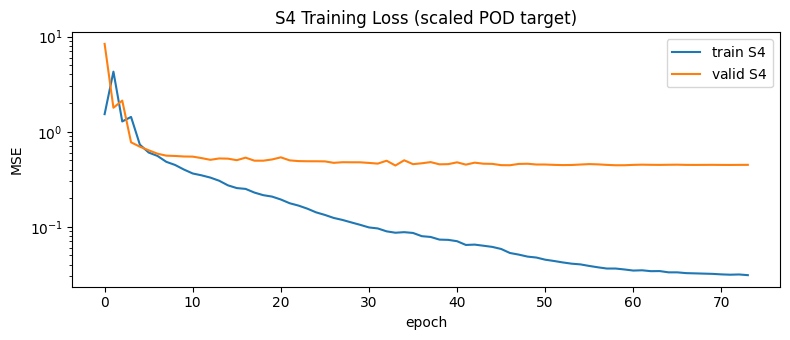

In [55]:
plt.figure(figsize=(8, 3.5))
plt.semilogy(tr_losses_s4, label='train S$4$')
plt.semilogy(vl_losses_s4, label='valid S$4$')
# plt.semilogy(tr_losses_di, label='train DiagSSM')
# plt.semilogy(vl_losses_di, label='valid DiagSSM')
plt.title('S4 Training Loss (scaled POD target)')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

## 7. POD Prediction Metrics + Full-Field Reconstruction

In [56]:
def predict_modes(model, X_data, batch_size=64):
    model.eval()
    Xt = torch.tensor(X_data, dtype=torch.float32).to(device)
    outs = []
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            outs.append(model(Xt[i:i + batch_size]).cpu().numpy())
    y_sc = np.concatenate(outs, axis=0)
    shp = y_sc.shape
    y_modes = y_scaler.inverse_transform(y_sc.reshape(-1, n_modes)).reshape(shp)
    return y_modes

def reconstruct_field(y_modes):
    # y_modes: [Nseq, T, n_modes] -> [Nseq, T, Nx]
    return (y_modes.reshape(-1, n_modes) @ Phi.T).reshape(
        y_modes.shape[0], y_modes.shape[1], Nx) + train_mean

def compute_split_metrics(split_name, X_sc, Y_modes_true, Y_full_true):
    Y_modes_pred = predict_modes(s4_model, X_sc)
    Y_full_pred  = reconstruct_field(Y_modes_pred)

    rmse_modes = np.sqrt(np.mean((Y_modes_pred - Y_modes_true) ** 2))
    rmse_field = np.sqrt(np.mean((Y_full_pred  - Y_full_true)  ** 2))
    mae_field  = np.mean(np.abs(Y_full_pred - Y_full_true))
    mre_field  = np.mean(
        np.sqrt(np.mean((Y_full_pred - Y_full_true) ** 2, axis=-1))
        / (np.sqrt(np.mean(Y_full_true ** 2, axis=-1)) + 1e-12)
    )
    return {
        'split': split_name,
        'rmse_modes': rmse_modes,
        'rmse_field': rmse_field,
        'mae_field':  mae_field,
        'mre_field_pct': 100.0 * mre_field,
        'Y_modes_pred': Y_modes_pred,
        'Y_full_pred':  Y_full_pred,
    }

train_res = compute_split_metrics('train', X_train_sc, Y_train_modes, Y_train_full)
valid_res = compute_split_metrics('valid', X_valid_sc, Y_valid_modes, Y_valid_full)
test_res  = compute_split_metrics('test',  X_test_sc,  Y_test_modes,  Y_test_full)

print('Metrics summary:')
for r in [train_res, valid_res, test_res]:
    print(
        f"{r['split']:>5} | "
        f"POD RMSE={r['rmse_modes']:.4e} | "
        f"Field RMSE={r['rmse_field']:.4e} | "
        f"Field MAE={r['mae_field']:.4e} | "
        f"Field MRE={r['mre_field_pct']:.2f}%"
    )

Y_pred_modes_train = train_res['Y_modes_pred']; Y_true_modes_train = Y_train_modes
Y_pred_field_train = train_res['Y_full_pred'];  Y_true_field_train = Y_train_full
Y_pred_modes_valid = valid_res['Y_modes_pred']; Y_true_modes_valid = Y_valid_modes
Y_pred_field_valid = valid_res['Y_full_pred'];  Y_true_field_valid = Y_valid_full
Y_pred_modes_test  = test_res['Y_modes_pred'];  Y_true_modes_test  = Y_test_modes
Y_pred_field_test  = test_res['Y_full_pred'];   Y_true_field_test  = Y_test_full


Metrics summary:
train | POD RMSE=3.0051e-03 | Field RMSE=7.8254e-04 | Field MAE=5.7739e-04 | Field MRE=20.70%
valid | POD RMSE=6.3997e-03 | Field RMSE=1.5883e-03 | Field MAE=1.0087e-03 | Field MRE=39.77%
 test | POD RMSE=8.1643e-03 | Field RMSE=2.0358e-03 | Field MAE=1.3680e-03 | Field MRE=57.43%



Visualising sequence 9 from train set:


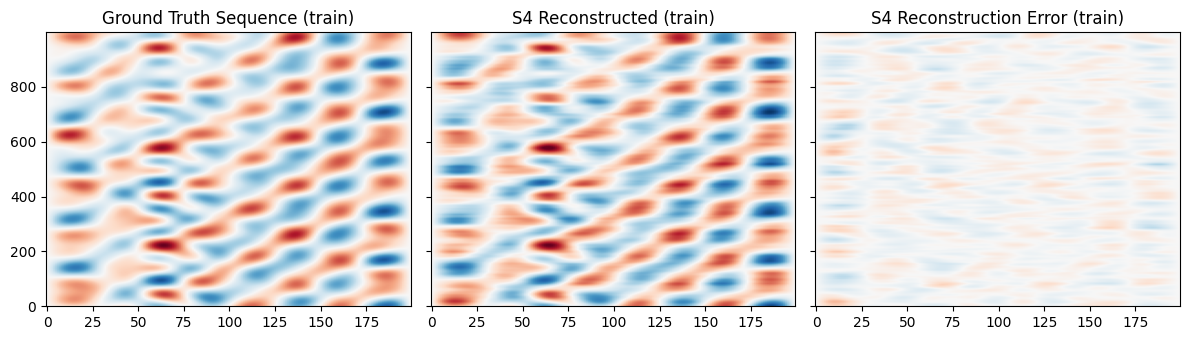

In [57]:

seq_i = np.random.randint(0, min(len(Y_true_field_train), len(Y_true_field_train)))
print(f'\nVisualising sequence {seq_i} from train set:')
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
v = np.max(np.abs(Y_true_field_train[seq_i]))
axes[0].imshow(Y_true_field_train[seq_i], aspect='auto', cmap='RdBu_r', origin='lower', vmin=-v, vmax=v)
axes[0].set_title('Ground Truth Sequence (train)')
axes[1].imshow(Y_pred_field_train[seq_i], aspect='auto', cmap='RdBu_r', origin='lower', vmin=-v, vmax=v)
axes[1].set_title('S4 Reconstructed (train)')
axes[2].imshow(Y_pred_field_train[seq_i] - Y_true_field_train[seq_i], aspect='auto', cmap='RdBu_r', origin='lower', vmin=-v, vmax=v)
axes[2].set_title('S4 Reconstruction Error (train)')

plt.tight_layout()
plt.show()


Visualising sequence 2 from valid set:


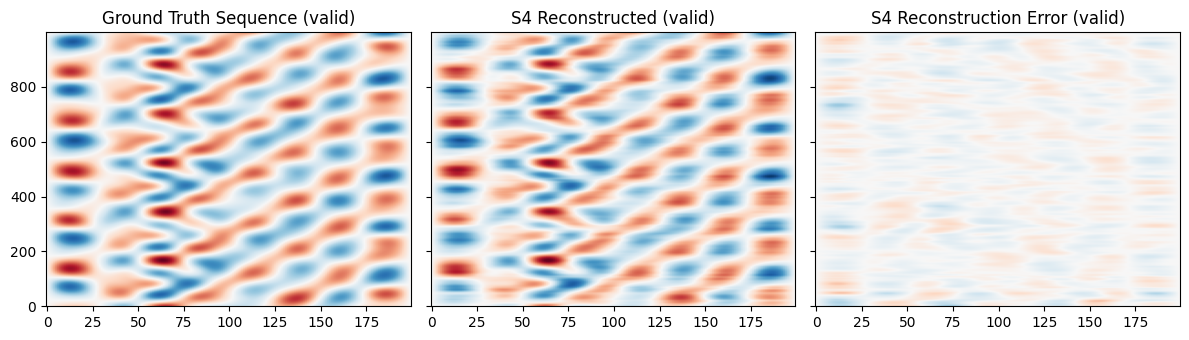

In [58]:

seq_i = np.random.randint(0, min(len(Y_true_field_valid), len(Y_true_field_valid)))
print(f'\nVisualising sequence {seq_i} from valid set:')
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
v = np.max(np.abs(Y_true_field_valid[seq_i]))
axes[0].imshow(Y_true_field_valid[seq_i], aspect='auto', cmap='RdBu_r', origin='lower', vmin=-v, vmax=v)
axes[0].set_title('Ground Truth Sequence (valid)')
axes[1].imshow(Y_pred_field_valid[seq_i], aspect='auto', cmap='RdBu_r', origin='lower', vmin=-v, vmax=v)
axes[1].set_title('S4 Reconstructed (valid)')
axes[2].imshow(Y_pred_field_valid[seq_i] - Y_true_field_valid[seq_i], aspect='auto', cmap='RdBu_r', origin='lower', vmin=-v, vmax=v)
axes[2].set_title('S4 Reconstruction Error (valid)')

plt.tight_layout()
plt.show()


Visualising sequence 1 from test set:


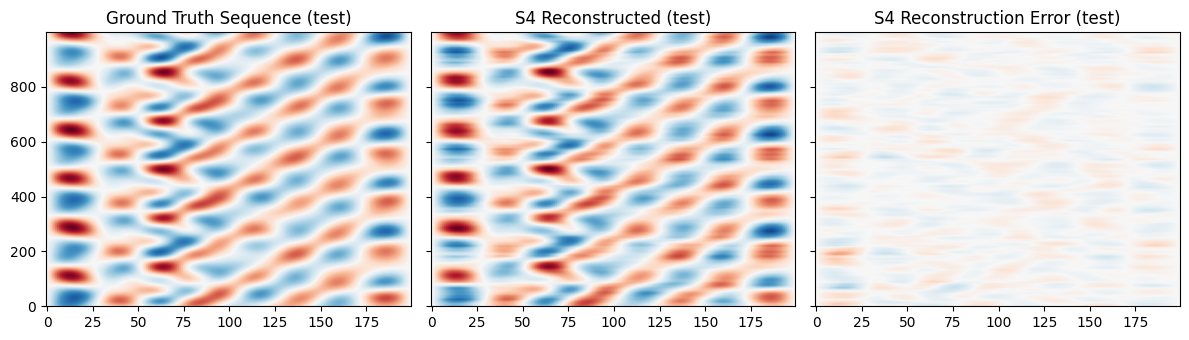

In [59]:

seq_i = np.random.randint(0, min(len(Y_true_field_test), len(Y_true_field_valid)))
print(f'\nVisualising sequence {seq_i} from test set:')
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
v = np.max(np.abs(Y_true_field_test[seq_i]))
axes[0].imshow(Y_true_field_test[seq_i], aspect='auto', cmap='RdBu_r', origin='lower', vmin=-v, vmax=v)
axes[0].set_title('Ground Truth Sequence (test)')
axes[1].imshow(Y_pred_field_test[seq_i], aspect='auto', cmap='RdBu_r', origin='lower', vmin=-v, vmax=v)
axes[1].set_title('S4 Reconstructed (test)')
axes[2].imshow(Y_pred_field_test[seq_i] - Y_true_field_test[seq_i], aspect='auto', cmap='RdBu_r', origin='lower', vmin=-v, vmax=v)
axes[2].set_title('S4 Reconstruction Error (test)')

plt.tight_layout()
plt.show()

## 8.1 Animation — Train

In [60]:
import matplotlib
import matplotlib.animation as animation
from IPython.display import HTML, display, Image

def make_animation(true_seq, pred_seq, sensor_idx, title_suffix=''):
    matplotlib.rcParams["animation.embed_limit"] = 100  # MB
    err_seq_t  = np.sqrt(np.mean((pred_seq - true_seq) ** 2, axis=1))
    sensor_true = true_seq[:, sensor_idx]
    mean_true   = sensor_true.mean(axis=1)
    x  = np.arange(true_seq.shape[1])
    tt = np.arange(true_seq.shape[0])
    n_frames = len(tt)
    print(f'Animating {n_frames} frames {title_suffix}')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ax0, ax1, ax2 = axes

    v = 1.05 * max(np.abs(true_seq).max(), np.abs(pred_seq).max())
    line_true, = ax0.plot(x, true_seq[0], 'k-', lw=2, label='Ground Truth')
    line_pred, = ax0.plot(x, pred_seq[0], color='tab:blue', lw=1.6, label='S4 prediction')
    pts_true = ax0.scatter(sensor_idx, true_seq[0, sensor_idx], color='k', s=28, zorder=4, label='True sensors')
    pts_pred = ax0.scatter(sensor_idx, pred_seq[0, sensor_idx], color='tab:blue', s=24, marker='x', zorder=5, label='Pred sensors')
    ax0.set_xlim(x.min(), x.max()); ax0.set_ylim(-v, v)
    ax0.set_title(f'Spatial Profile {title_suffix}'); ax0.legend(loc='upper right')

    ax1.plot(tt, err_seq_t, color='tab:blue', alpha=0.25)
    line_err_hist, = ax1.plot([], [], color='tab:blue', lw=2, label='RMSE(t)')
    pt_err, = ax1.plot([tt[0]], [err_seq_t[0]], 'o', color='tab:red', ms=5)
    ax1.set_xlim(tt.min(), tt.max()); ax1.set_ylim(0.0, 1.05 * max(err_seq_t.max(), 1e-8))
    ax1.set_title('Error Trajectory'); ax1.legend(loc='upper right')

    for j in range(len(sensor_idx)):
        ax2.plot(tt, sensor_true[:, j], color='k', alpha=0.18, lw=1)
    line_s_true,  = ax2.plot(tt, mean_true, 'k-', lw=2, label='Mean sensor true')
    line_t_sensor = ax2.axvline(tt[0], color='tab:red', ls='--', lw=1.5)
    ys  = sensor_true.reshape(-1)
    pad = 0.05 * (ys.max() - ys.min() + 1e-8)
    ax2.set_xlim(tt.min(), tt.max()); ax2.set_ylim(ys.min() - pad, ys.max() + pad)
    ax2.set_title('Sensor Values Over Time'); ax2.set_xlabel('time in sequence'); ax2.legend(loc='upper right')

    time_text = fig.text(0.5, 0.01, '', ha='center')

    def init():
        line_true.set_ydata(true_seq[0]); line_pred.set_ydata(pred_seq[0])
        pts_true.set_offsets(np.c_[sensor_idx, true_seq[0, sensor_idx]])
        pts_pred.set_offsets(np.c_[sensor_idx, pred_seq[0, sensor_idx]])
        line_err_hist.set_data([tt[0]], [err_seq_t[0]])
        pt_err.set_data([tt[0]], [err_seq_t[0]])
        line_t_sensor.set_xdata([tt[0], tt[0]])
        time_text.set_text('t = 0')
        return [line_true, line_pred, pts_true, pts_pred, line_err_hist, pt_err, line_t_sensor, line_s_true, time_text]

    def update(frame):
        line_true.set_ydata(true_seq[frame]); line_pred.set_ydata(pred_seq[frame])
        pts_true.set_offsets(np.c_[sensor_idx, true_seq[frame, sensor_idx]])
        pts_pred.set_offsets(np.c_[sensor_idx, pred_seq[frame, sensor_idx]])
        line_err_hist.set_data(tt[:frame + 1], err_seq_t[:frame + 1])
        pt_err.set_data([tt[frame]], [err_seq_t[frame]])
        line_t_sensor.set_xdata([tt[frame], tt[frame]])
        time_text.set_text(f't = {frame}/{n_frames - 1}')
        return [line_true, line_pred, pts_true, pts_pred, line_err_hist, pt_err, line_t_sensor, line_s_true, time_text]

    ani = animation.FuncAnimation(fig, update, init_func=init, frames=n_frames, interval=80, blit=True, repeat=True)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    try:
        display(HTML(ani.to_jshtml(fps=30, default_mode='once')))
    except Exception as e:
        print('jshtml failed, falling back to GIF:', e)
        gif_path = Path(f'figures/viv_anim{title_suffix.replace(" ","_")}.gif')
        gif_path.parent.mkdir(parents=True, exist_ok=True)
        ani.save(gif_path, writer=animation.PillowWriter(fps=30))
        display(Image(filename=str(gif_path)))
    plt.close(fig)


import matplotlib.animation as animation
from IPython.display import HTML, display

def make_modes_animation(y_true_seq, y_pred_seq, split_name='train'):
    """
    Create animation showing all POD mode coefficients at each time step.
    
    Parameters:
    y_true_seq: array of shape [n_timesteps, n_modes] - true mode coefficients
    y_pred_seq: array of shape [n_timesteps, n_modes] - predicted mode coefficients
    split_name: string for plot title ('train', 'valid', 'test')
    """
    n_timesteps, n_modes = y_true_seq.shape
    
    
    
    # Compute per-timestep and per-mode errors
    error_seq_t = np.sqrt(np.mean((y_pred_seq - y_true_seq) ** 2, axis=1))  # [n_timesteps]
    
    mode_idx = np.arange(n_modes)
    tt = np.arange(n_timesteps)
    
    print(f'Animating {n_timesteps} frames for {split_name} set')
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    ax0, ax1, ax2 = axes
    
    # Left: All mode coefficients at current time
    v = 1.05 * max(np.abs(y_true_seq).max(), np.abs(y_pred_seq).max())
    line_true, = ax0.plot(mode_idx, y_true_seq[0], 'ko-', lw=2, markersize=6, label='True')
    line_pred, = ax0.plot(mode_idx, y_pred_seq[0], 'b^-', lw=2, markersize=5, label='Predicted')
    ax0.set_xlim(mode_idx.min() - 0.5, mode_idx.max() + 0.5)
    ax0.set_ylim(-v, v)
    ax0.set_xlabel('Mode Index')
    ax0.set_ylabel('Coefficient Value')
    ax0.set_title(f'Mode Coefficients {split_name.upper()}')
    ax0.grid(True, alpha=0.3)
    ax0.legend(loc='upper right')
    
    # Middle: Error trajectory over time
    ax1.plot(tt, error_seq_t, color='tab:blue', alpha=0.25)
    line_err_hist, = ax1.plot([], [], color='tab:blue', lw=2, label='RMSE(t)')
    pt_err, = ax1.plot([tt[0]], [error_seq_t[0]], 'o', color='tab:red', ms=6)
    ax1.set_xlim(tt.min(), tt.max())
    ax1.set_ylim(0.0, 1.05 * max(error_seq_t.max(), 1e-8))
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('RMSE')
    ax1.set_title('Total Error Trajectory')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')
    
    # Right: Per-mode absolute error over time
    for m in range(n_modes):
        mode_error_t = np.abs(y_pred_seq[:, m] - y_true_seq[:, m])
        ax2.plot(tt, mode_error_t, alpha=0.4, lw=0.8)
    
    pt_mode_error, = ax2.plot([], [], 'o', color='tab:red', ms=8, label='Current errors')
    ax2.set_xlim(tt.min(), tt.max())
    ax2.set_ylim(0, np.abs(y_pred_seq - y_true_seq).max() * 1.1)
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Absolute Error')
    ax2.set_title('Individual Mode Errors')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')
    
    time_text = fig.text(0.5, 0.01, '', ha='center', fontsize=11)
    
    def init():
        line_true.set_ydata(y_true_seq[0])
        line_pred.set_ydata(y_pred_seq[0])
        line_err_hist.set_data([tt[0]], [error_seq_t[0]])
        pt_err.set_data([tt[0]], [error_seq_t[0]])
        pt_mode_error.set_data([], [])
        time_text.set_text('t = 0')
        return [line_true, line_pred, line_err_hist, pt_err, pt_mode_error, time_text]
    
    def update(frame):
        # Update mode coefficients
        line_true.set_ydata(y_true_seq[frame])
        line_pred.set_ydata(y_pred_seq[frame])
        
        # Update error trajectory
        line_err_hist.set_data(tt[:frame + 1], error_seq_t[:frame + 1])
        pt_err.set_data([tt[frame]], [error_seq_t[frame]])
        
        # Update per-mode error points at current time
        current_errors = np.abs(y_pred_seq[frame] - y_true_seq[frame])
        error_times = np.full(n_modes, frame)
        pt_mode_error.set_data(error_times, current_errors)
        
        time_text.set_text(f't = {frame}/{n_timesteps - 1}')
        
        return [line_true, line_pred, line_err_hist, pt_err, pt_mode_error, time_text]
    
    ani = animation.FuncAnimation(fig, update, init_func=init, frames=n_timesteps, 
                                   interval=80, blit=True, repeat=True)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    
    try:
        display(HTML(ani.to_jshtml(fps=30, default_mode='once')))
    except Exception as e:
        print('jshtml failed, falling back to GIF:', e)
        gif_path = Path(f'figures/viv_modes_anim_{split_name}.gif')
        gif_path.parent.mkdir(parents=True, exist_ok=True)
        ani.save(gif_path, writer=animation.PillowWriter(fps=30))
        display(Image(filename=str(gif_path)))
    
    plt.close(fig)



In [ ]:
seq_i = np.random.randint(0, min(len(Y_true_field_train), len(Y_true_field_train)))
print(f'\nCreating animations for sequence {seq_i} from train set:')
make_animation(Y_true_field_train[seq_i], Y_pred_field_train[seq_i], sensor_idx, title_suffix='(train)')
make_modes_animation(Y_true_modes_train[seq_i], Y_pred_modes_train[seq_i], split_name='train')


Creating animations for sequence 14 from train set:
Animating 1000 frames (train)


Animation size has reached 104888115 bytes, exceeding the limit of 104857600.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


## 8.2 Animation — Valid


Creating animations for sequence 1 from valid set:
Animating 1000 frames (valid)


KeyboardInterrupt: 

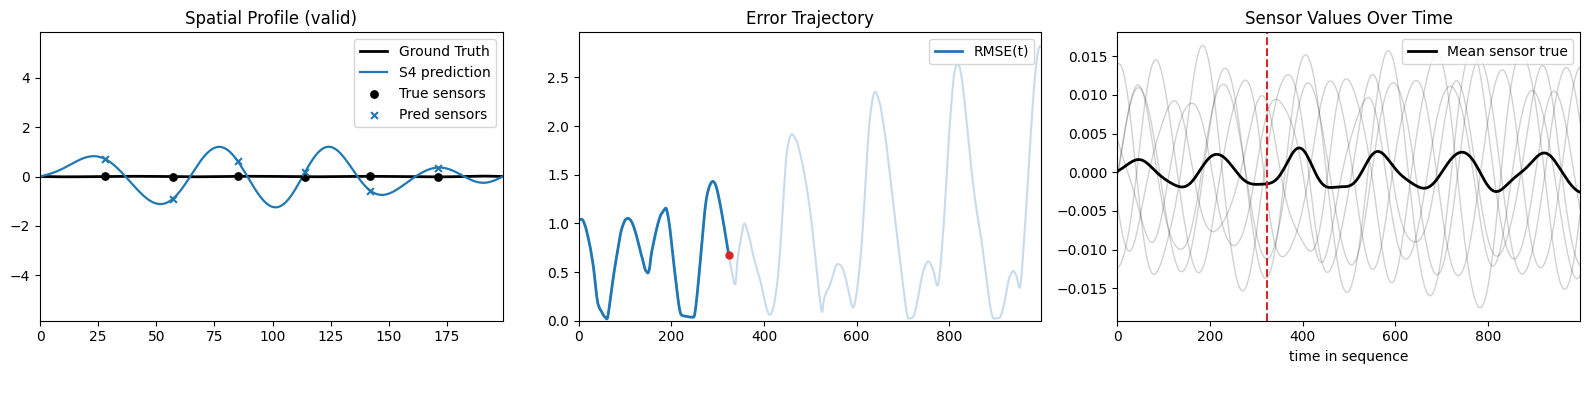

In [ ]:
seq_i = np.random.randint(0, min(len(Y_true_field_valid), len(Y_true_field_valid)))
print(f'\nCreating animations for sequence {seq_i} from valid set:')

make_animation(Y_true_field_valid[seq_i], Y_pred_field_valid[seq_i], sensor_idx, title_suffix='(valid)')
make_modes_animation(Y_true_modes_valid[seq_i], Y_pred_modes_valid[seq_i], split_name='valid')

## 8.3 Animation — Test


Creating animations for sequence 5 from test set:
Animating 1000 frames (test)


Animation size has reached 105007258 bytes, exceeding the limit of 104857600.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


KeyboardInterrupt: 

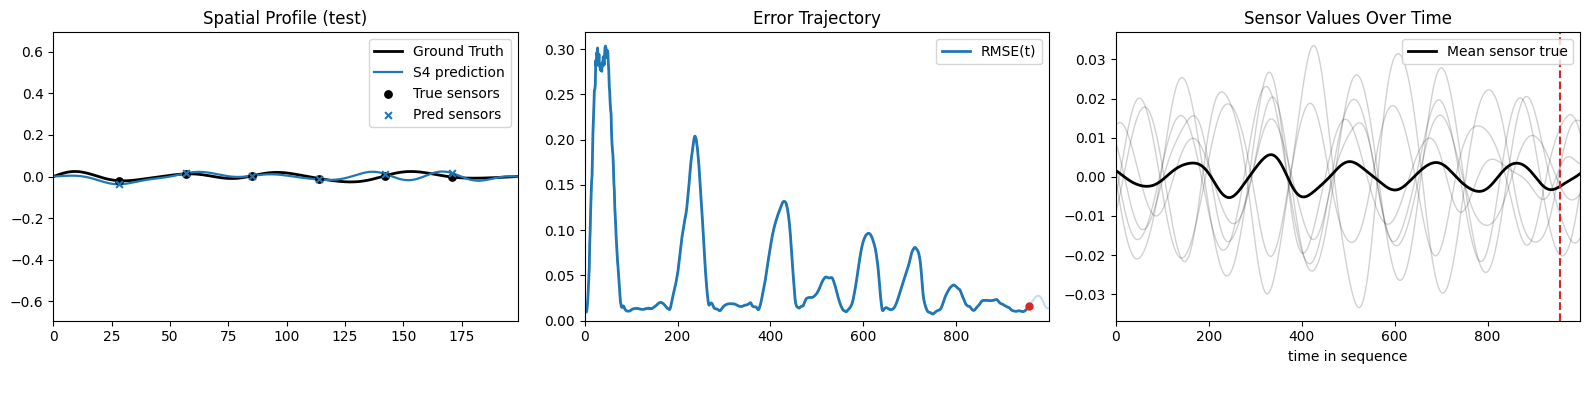

In [ ]:
seq_i = np.random.randint(0, min(len(Y_true_field_test), len(Y_true_field_valid)))
print(f'\nCreating animations for sequence {seq_i} from test set:')
make_animation(Y_true_field_test[seq_i], Y_pred_field_test[seq_i], sensor_idx, title_suffix='(test)')
make_modes_animation(Y_true_modes_test[seq_i], Y_pred_modes_test[seq_i], split_name='test')